In [108]:
import torch
import numpy as np
import pandas as pd
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from PIL import Image

import tarfile
import io

from helper_functions import show_masks

In [109]:
# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


In [110]:
# Function to predict the mask of an image
def predictMask(img, predictor, input_point = np.empty((0, 2)), input_label = np.empty((0,), dtype=int)):    
    predictor.set_image(img)
    pred_masks, scores, logits = predictor.predict(
        point_coords = input_point,
        point_labels = input_label,
        multimask_output = False
     )
    return pred_masks, scores, logits

In [111]:
# Define the pretrained model configuration you want to use
modelPath = "../sam2_river_masking.pt"
metaDataPath = "../mask_meta.csv"
metaData = pd.read_csv(metaDataPath)
metaData = metaData[metaData['rapid_split'] != 'train']

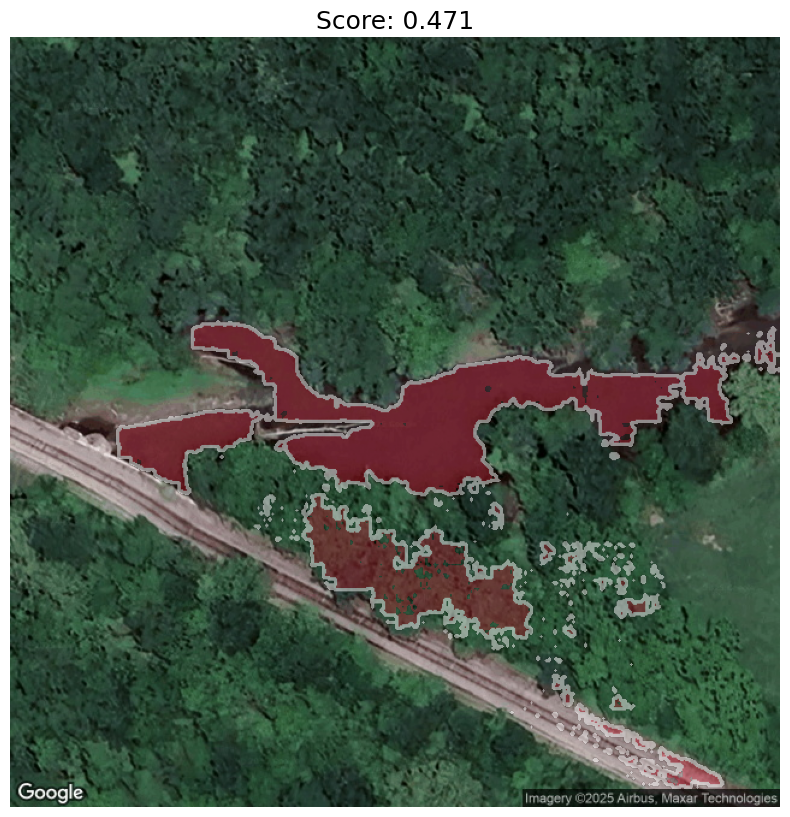

In [112]:
sam2_checkpoint = "../../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "./configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor1 = SAM2ImagePredictor(sam2_model)
# Load the model state that we trained
predictor1.model.load_state_dict(torch.load(modelPath))

tar_path = "../mask_dataset.tar"
key = metaData["image"].iloc[22]
key_img = key + ".jpg"
key_mask = key + ".npy"
with tarfile.open(tar_path, "r") as tar:
    member_dict = {m.name: m for m in tar.getmembers()}
    member = member_dict[key_img]
    file = tar.extractfile(member)
    image = Image.open(file).convert("RGB")

pred_masks, scores, logits = predictMask(image, predictor1)
show_masks(image, pred_masks, scores, borders=True)

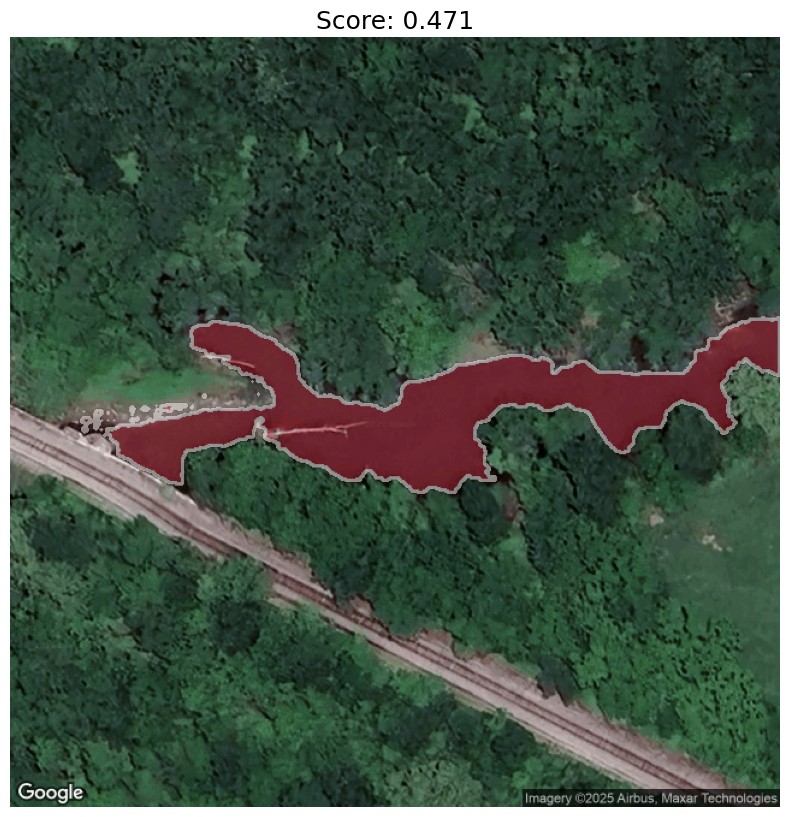

In [113]:
with tarfile.open(tar_path, "r") as tar:
    member_dict = {m.name: m for m in tar.getmembers()}
    member = member_dict[key_img]
    file = tar.extractfile(member)
    image = Image.open(file).convert("RGB")
    mask_member = member_dict[key_mask]
    mask_file = tar.extractfile(mask_member)
    mask_content = mask_file.read()
    mask = np.load(io.BytesIO(mask_content))
    mask = np.unpackbits(mask, axis=-1)

pred_masks, scores, logits = predictMask(image, predictor1)
mask = mask.reshape(1, mask.shape[0], mask.shape[1])
show_masks(image, mask, scores, borders=True)

In [114]:
def iou_score(mask_true, mask_pred):
    # Ensure binary masks (0 or 1)
    mask_true = mask_true.astype(bool)
    mask_pred = mask_pred.astype(bool)
    
    intersection = np.logical_and(mask_true, mask_pred).sum()
    union = np.logical_or(mask_true, mask_pred).sum()
    
    if union == 0:
        return 1.0  # Both empty — define IoU as perfect match
    else:
        return intersection / union
    

iou = iou_score(mask, pred_masks)
print(f"IoU score: {iou:.4f}")


IoU score: 0.5587


In [115]:
metaData['mask_score'] = 0.0
metaData['iou_score'] = 0.0

In [116]:
ious = []

for i in range(metaData.shape[0]):
    key = metaData["image"].iloc[i]
    key_img = key + ".jpg"
    key_mask = key + ".npy"
    with tarfile.open(tar_path, "r") as tar:
        member_dict = {m.name: m for m in tar.getmembers()}
        member = member_dict[key_img]
        file = tar.extractfile(member)
        image = Image.open(file).convert("RGB")
        mask_member = member_dict[key_mask]
        mask_file = tar.extractfile(mask_member)
        mask_content = mask_file.read()
        mask = np.load(io.BytesIO(mask_content))
        mask = np.unpackbits(mask, axis=-1)

    pred_masks, scores, logits = predictMask(image, predictor1)
    mask = mask.reshape(1, mask.shape[0], mask.shape[1])
    iou = iou_score(mask, pred_masks)
    ious.append(iou)
    metaData.loc[metaData['image'] == key, 'mask_score'] = scores[0]
    metaData.loc[metaData['image'] == key, 'iou_score'] = iou
    print(f"Mask Score: {scores[0]:.4f}, IoU Score: {iou:.4f} for image {key}")

metaDataClean = metaData[['image', 'mask_score', 'iou_score']]
print(metaDataClean.head())
metaDataClean.to_csv("mask_scores.csv", index=False)

Mask Score: 0.3867, IoU Score: 0.0369 for image h010300_-69~7538055_44~6854904_z19
Mask Score: 0.3672, IoU Score: 0.2815 for image h010500_-67~3891662_44~7384418_z19
Mask Score: 0.2852, IoU Score: 0.0042 for image h010500_-67~9941013_44~5866337_z19
Mask Score: 0.9141, IoU Score: 0.9517 for image h010600_-70~4973221_43~4982171_z19
Mask Score: 0.8086, IoU Score: 0.0000 for image h010600_-70~71347_43~4098167_z19
Mask Score: 0.2227, IoU Score: 0.1284 for image h010600_-70~9456732_42~9610999_z19
Mask Score: 0.4531, IoU Score: 0.1003 for image h010600_-71~1583054_43~001357_z19
Mask Score: 0.7305, IoU Score: 0.1653 for image h020401_-74~6291462_41~579431_z19
Mask Score: 0.9297, IoU Score: 0.9547 for image h020402_-75~920276_40~3097947_z19
Mask Score: 0.4766, IoU Score: 0.9676 for image h030300_-77~9055437_34~6585658_z19
Mask Score: 0.6836, IoU Score: 0.7957 for image h030300_-79~266477_35~9084262_z19
Mask Score: 0.3691, IoU Score: 0.0000 for image h030701_-82~6451381_32~188507_z19
Mask Score:

In [117]:
rows = []

test_score = 0
while test_score < 1:
    test_data = metaDataClean[metaDataClean['mask_score'] >= test_score]
    if not test_data.empty:
        avg_iou = test_data['iou_score'].mean()
        rows.append((test_score, avg_iou))
    test_score += 0.05

avg_ious = pd.DataFrame(rows, columns=['min_mask_score', 'avg_iou'])
print(avg_ious)

avg_ious.to_csv("avg_ious.csv", index=False)

    min_mask_score   avg_iou
0             0.00  0.383303
1             0.05  0.383303
2             0.10  0.383303
3             0.15  0.381677
4             0.20  0.381677
5             0.25  0.382870
6             0.30  0.386533
7             0.35  0.394806
8             0.40  0.408972
9             0.45  0.426898
10            0.50  0.431570
11            0.55  0.441612
12            0.60  0.461350
13            0.65  0.495746
14            0.70  0.509984
15            0.75  0.541323
16            0.80  0.583124
17            0.85  0.695818
18            0.90  0.802310
19            0.95  0.862900
